In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
print("Loading Fashion MNIST dataset....")

X,y = fetch_openml(
    'Fashion-MNIST',
    version=1,
    return_X_y=True,
    as_frame=False
    
)

x = X.astype('float32')
y = y.astype('int')


print("Dataset shape:",x.shape)

Loading Fashion MNIST dataset....
Dataset shape: (70000, 784)


In [3]:
X=X[:10000]
y=y[:10000]

In [4]:
X_train, X_test, y_train, y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:",X_test.shape[0])

Training samples: 8000
Testing samples: 2000


In [5]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [6]:
print("\nTraining Linear SVM...")
linear_svm=SVC(kernel='linear')
linear_svm.fit(X_train,y_train)
y_pred_linear=linear_svm.predict(X_test)
linear_accuracy=accuracy_score(y_test,y_pred_linear)
print("Linear SVM Accuracy:",
      linear_accuracy * 100,"%")


Training Linear SVM...
Linear SVM Accuracy: 80.75 %


In [7]:
print("\nTraining RBF SVM...")

rbf_svm=SVC(
    kernel='rbf',
    gamma='scale'
)

rbf_svm.fit(X_train,y_train)
y_pred_rbf=rbf_svm.predict(X_test)
rbf_accuracy=accuracy_score(y_test,y_pred_rbf)
print("RBF SVM Accuracy:",
      rbf_accuracy * 100,"%")



Training RBF SVM...
RBF SVM Accuracy: 85.25 %


In [8]:
print("\n--Linear SVM Classification Report___")
print(classification_report(y_test,y_pred_linear))
print("\n---RBF SVM Classification Report ---")
print(classification_report(y_test,y_pred_rbf))


--Linear SVM Classification Report___
              precision    recall  f1-score   support

           0       0.68      0.83      0.74       189
           1       0.95      0.97      0.96       205
           2       0.64      0.71      0.67       203
           3       0.83      0.79      0.81       204
           4       0.65      0.62      0.63       195
           5       0.91      0.92      0.91       198
           6       0.63      0.50      0.55       204
           7       0.89      0.89      0.89       204
           8       0.97      0.95      0.96       198
           9       0.92      0.92      0.92       200

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000


---RBF SVM Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       189
           1       1.00      0.96      0.98       205
 

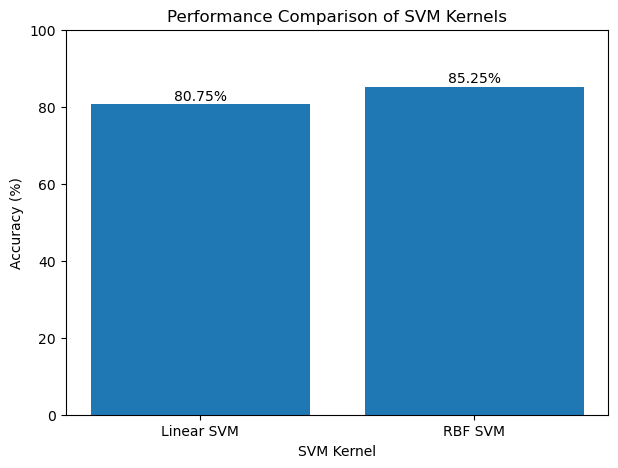

In [9]:
models=['Linear SVM','RBF SVM']
accuracy= [linear_accuracy * 100, rbf_accuracy*100]
plt.figure(figsize=(7,5))
bars=plt.bar(models,accuracy)
plt.ylabel("Accuracy (%)")
plt.xlabel("SVM Kernel")
plt.title("Performance Comparison of SVM Kernels")
plt.ylim(0,100)
for bar,value in zip(bars,accuracy):
    plt.text(
        bar.get_x()+bar.get_width()/2,
        value+1,
        f"{value:.2f}%",
        ha='center'
    )
plt.show()
    

